In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import class_likelihood_ratios

import warnings
warnings.filterwarnings('ignore')

In [7]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\Logistic_Regression_Assignment\Bank Customer Churn Prediction.csv")
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [12]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [13]:
categorical_col=df.select_dtypes(include='object').columns


for col in categorical_col:
    print(col,":",df[col].unique())

country : ['France' 'Spain' 'Germany']
gender : ['Female' 'Male']


# INTERVIEW Q1:
# Why data cleaning is critical in banking churn?
# ---------------------------
"""
In financial services, poor data quality can lead to incorrect churn risk predictions,
causing banks to either lose valuable customers or waste retention budgets.
Clean data ensures regulatory compliance, reliable risk assessment, and trust in decisions.
"""

2. Customer Segments & EDA
Create tenure buckets:
New (Tenure ≤ 6 months)
Moderate (7–24 months)
Loyal (> 24 months)
Plot churn percentage for each bucket.
Interpret which tenure group churns most.
Suggest one business action banks might take based on this result.

In [14]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [15]:
# Customer sigment EDA
df['Tenure_group']=pd.cut(
    df['tenure'],
    bins=[-1,6,24,100],
    labels=['New','Moderate','Loyal']
)

In [16]:
# verify the bucket
tenure_churn=df.groupby('Tenure_group')['churn'].mean()*100

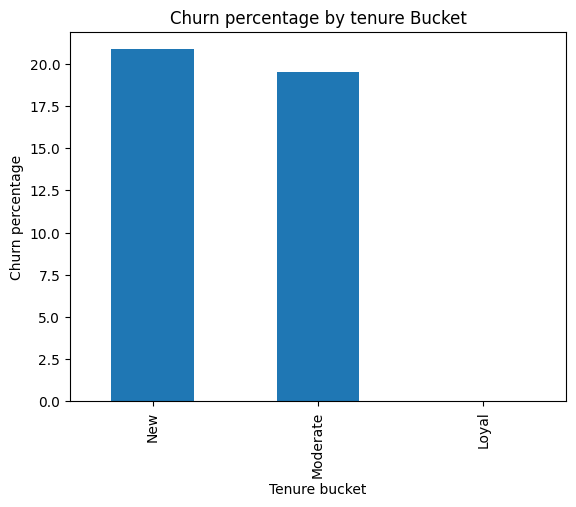

In [17]:
# PLot churn percentage
tenure_churn.plot(kind='bar')
plt.title("Churn percentage by tenure Bucket")
plt.xlabel("Tenure bucket")
plt.ylabel("Churn percentage")
plt.show()

Analyze churn rate by:
Contract or product type (e.g., CreditCard status, Product holding)
Geography or customer segment


In [18]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group'],
      dtype='object')

In [19]:
# Credit_card vs churn
creditcard_churn=df.groupby('credit_card')['churn'].mean()*100
creditcard_churn

credit_card
0    20.814941
1    20.184266
Name: churn, dtype: float64

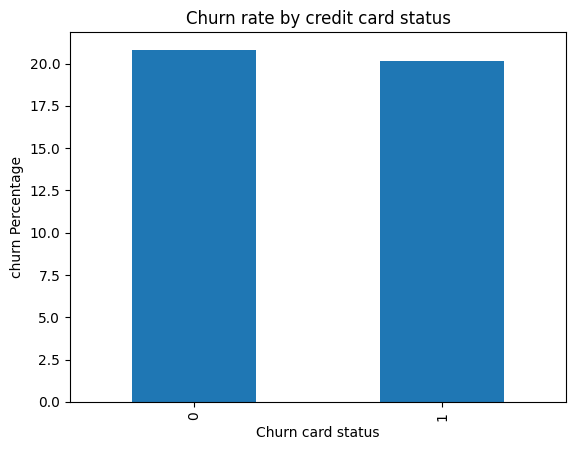

In [20]:

creditcard_churn.plot(kind='bar')
plt.ylabel("churn Percentage")
plt.xlabel("Churn card status")
plt.title("Churn rate by credit card status")
plt.show()

In [21]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group'],
      dtype='object')

In [22]:
# Product holding vs churn
product_churn=df.groupby('products_number')['churn'].mean()*100
product_churn

products_number
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64

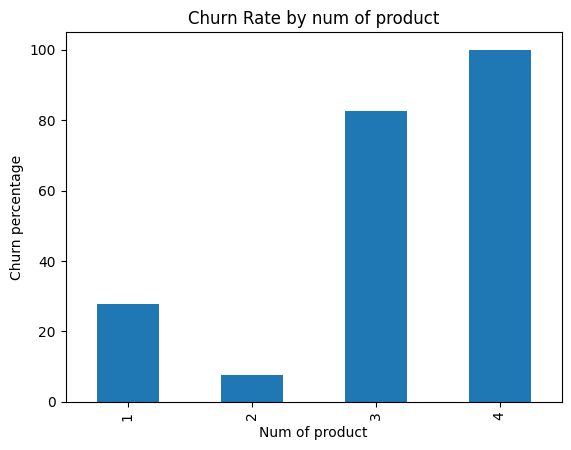

In [23]:
product_churn.plot(kind='bar')
plt.title("Churn Rate by num of product")
plt.xlabel("Num of product")
plt.ylabel("Churn percentage")
plt.show()

5.Convert financial variables (e.g., Balance, EstimatedSalary) to numeric if not already numeric.


In [24]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group'],
      dtype='object')

In [25]:
balance_median=df['balance'].median()
df['HighBalance']=np.where(df['balance']>balance_median,1,0)

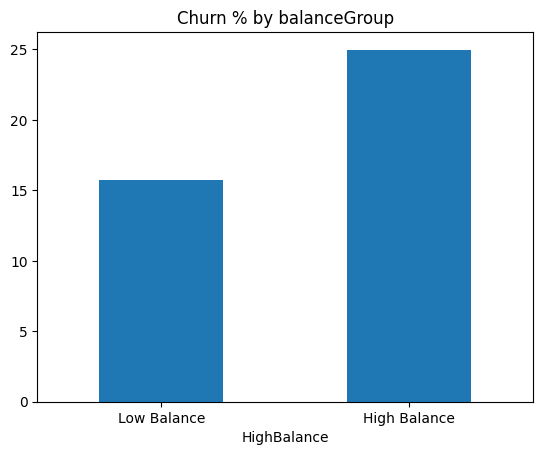

In [26]:
balance_churn=df.groupby('HighBalance')['churn'].mean()*100
balance_churn.plot(kind='bar')
plt.title("Churn % by balanceGroup")
plt.xticks([0,1],['Low Balance','High Balance'],rotation=0)
plt.show()

In [27]:
# 6.Using the median of these variables, define:
# High revenue group (> median)
# Low revenue group (≤ median)

# median
balance_median=df['balance'].median()
salary_median=df['estimated_salary'].median()

balance_median,salary_median

(np.float64(97198.54000000001), np.float64(100193.915))

In [28]:
# Create Revenue Group
df['Balance_group']=df['balance'].apply(
    lambda x:'High Revenue' if x>balance_median else 'Low Revenue'
)

df['salary_group']=df['estimated_salary'].apply(
    lambda x:'High Revenue' if x>salary_median else 'Low revenue'
    )

In [29]:
df[['balance','Balance_group', 'estimated_salary','salary_group']].head()

,balance,Balance_group,estimated_salary,salary_group
0,0.00,Low Revenue,101348.88,High Revenue
1,83807.86,Low Revenue,112542.58,High Revenue
2,159660.80,High Revenue,113931.57,High Revenue
3,0.00,Low Revenue,93826.63,Low revenue
4,125510.82,High Revenue,79084.10,Low revenue


In [30]:
df['Balance_group'].value_counts()
df['salary_group'].value_counts()

salary_group
High Revenue    5000
Low revenue     5000
Name: count, dtype: int64

In [31]:
# Plot churn percentages for each group.
balance_churn=df.groupby('Balance_group')['churn'].mean()*100
balance_churn

Balance_group
High Revenue    24.98
Low Revenue     15.76
Name: churn, dtype: float64

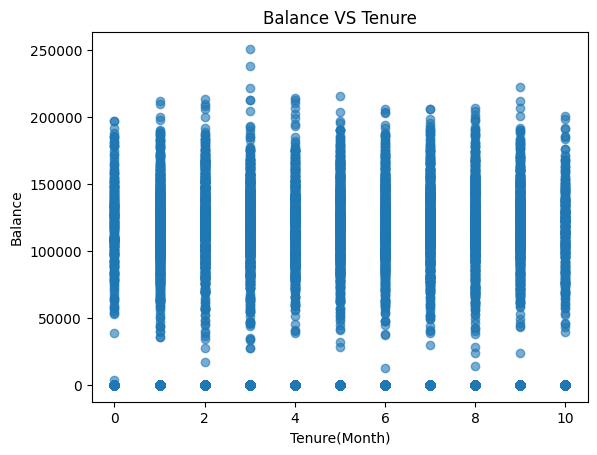

In [32]:
# 8 .Visualize interactions:
# Scatter / heatmap for Balance vs Tenure
# Credit Score vs Estimated Salary

plt.scatter(df['tenure'],df['balance'],alpha=0.6)
plt.xlabel('Tenure(Month)')
plt.ylabel('Balance')
plt.title("Balance VS Tenure")
plt.show()

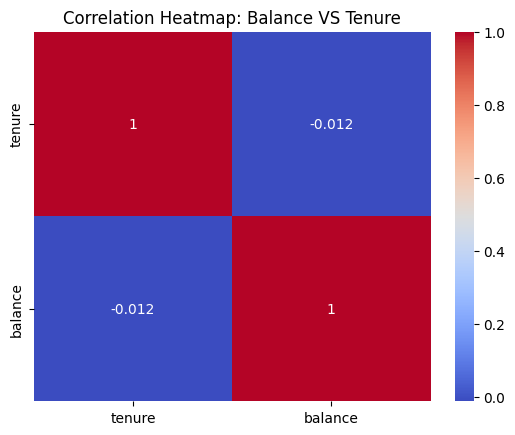

In [33]:
corr_bt=df[['tenure','balance']].corr()
sns.heatmap(corr_bt,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap: Balance VS Tenure")
plt.show()

In [34]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group', 'HighBalance',
       'Balance_group', 'salary_group'],
      dtype='object')

Create combined profiles:
Risk Profile-A: Older customers with low balance
Risk Profile-B: Young customers with high balance
Compare churn % between these groups.

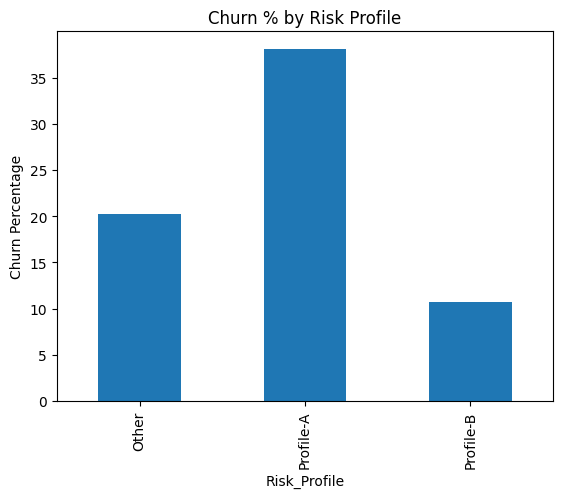

In [ ]:


df['Risk_Profile'] = np.where(
    (df['age'] > 45) & (df['balance'] < balance_median),
    'Profile-A',
    np.where(
        (df['age'] < 35) & (df['balance'] > balance_median),
        'Profile-B',
        'Other'
    )
)

risk_churn = df.groupby('Risk_Profile')['churn'].mean() * 100

risk_churn.plot(kind='bar', title='Churn % by Risk Profile')
plt.ylabel("Churn Percentage")
plt.show()


In [41]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'Tenure_group', 'HighBalance',
       'Balance_group', 'salary_group', 'Risk_Profile'],
      dtype='object')

10.Compute association metrics (e.g., chi-square for categorical features vs churn) and correlation scores for numeric features.
11.Identify most statistically significant predictors of churn.

In [46]:
from scipy.stats import chi2_contingency

categorical_feature=['gender','credit_card','active_member','country','products_number']
chi_square_results=[]
for col in categorical_feature:
    contengency_table=pd.crosstab(df[col],df['churn'])
    chi2,p,dof,expected=chi2_contingency(contengency_table)

    chi_square_results.append({
        'Feature':col,'chi-square':chi2,'p-value':p
    })

chi_square_df =pd.DataFrame(chi_square_results).sort_values('p-value')
chi_square_df

,Feature,chi-square,p-value
4,products_number,1503.629362,0.000000e+00
3,country,301.255337,3.830318e-66
2,active_member,242.985342,8.785858e-55
0,gender,112.918571,2.248210e-26
1,credit_card,0.471338,4.923724e-01


12. Create at least two new features, for example:
HighBalanceFlag (Balance > median)
MultiProductFlag (Customers holding >1 product)